In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr
from scipy.stats import pearsonr
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import anderson, probplot
from scipy.stats import kstest
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
import scipy.linalg as la
import statsmodels.api as sm
from scipy.stats import beta
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

### Extract Data

In [85]:
df_returns = pd.read_csv(r'C:\Users\Windows 10\OneDrive\Desktop\Coding\Stat Comp\Project\Data\mag7_nasdaq_returns.csv')
df_returns.drop(columns=['Unnamed: 0'], inplace=True)
df_returns['Date_Return'] = pd.to_datetime(df_returns['Date_Return'])
df_returns = df_returns.set_index('Date_Return')
df_returns.head()

,AAPL_Return,AMZN_Return,WTI_Crude_Oil_Return,Dollar_Index_Return,COMEX_Gold_Return,GOOGL_Return,META_Return,MSFT_Return,NVDA_Return,Treasury_Inflation_Return,TSLA_Return,Nasdaq_Return,VIX_Fear_Index_Return
Date_Return,,,,,,,,,,,,,
2021-01-05,0.012364,0.010004,0.048509,-0.004895,0.004114,0.008064,0.007548,0.000965,0.022210,-0.000313,0.007317,0.009490,-0.060437
2021-01-06,-0.033662,-0.024897,0.014020,0.001006,-0.023455,-0.009868,-0.028269,-0.025929,-0.058953,-0.002975,0.028390,-0.006098,-0.010655
2021-01-07,0.034123,0.007577,0.003950,0.003351,0.002832,0.029869,0.020622,0.028457,0.057830,-0.000628,0.079447,0.025641,-0.107698
2021-01-08,0.008631,0.006496,0.027740,0.003006,-0.040893,0.013239,-0.004354,0.006093,-0.005040,-0.003928,0.078403,0.010293,-0.036209
2021-01-11,-0.023249,-0.021519,0.000191,0.004883,0.008451,-0.023106,-0.040102,-0.009699,0.025967,-0.002130,-0.078214,-0.012540,0.116883


### Modeling

In [86]:
y = df_returns['Nasdaq_Return']
x = df_returns.drop(columns=['Nasdaq_Return'])

### adjust format of x to include constant term
X = sm.add_constant(x)

### VIF Checking

In [87]:
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data)

                      feature       VIF
0                       const  1.025984
1                 AAPL_Return  2.121307
2                 AMZN_Return  2.308872
3        WTI_Crude_Oil_Return  1.053526
4         Dollar_Index_Return  1.323992
5           COMEX_Gold_Return  1.297946
6                GOOGL_Return  2.160408
7                 META_Return  1.858232
8                 MSFT_Return  2.679391
9                 NVDA_Return  1.974749
10  Treasury_Inflation_Return  1.200582
11                TSLA_Return  1.511492
12      VIX_Fear_Index_Return  1.710372


### Summary Model

In [88]:
MLR_model = sm.OLS(y, X).fit()
print(MLR_model.summary())

                            OLS Regression Results                            
Dep. Variable:          Nasdaq_Return   R-squared:                       0.947
Model:                            OLS   Adj. R-squared:                  0.947
Method:                 Least Squares   F-statistic:                     1867.
Date:                Sat, 28 Feb 2026   Prob (F-statistic):               0.00
Time:                        10:34:49   Log-Likelihood:                 5405.5
No. Observations:                1256   AIC:                        -1.078e+04
Df Residuals:                    1243   BIC:                        -1.072e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

### Predict Nasdaq Stock with β (Beta)

In [89]:
ones = np.ones((X.shape[0], 1))
X_matrix = np.hstack((ones, X))
beta, _, _, _ = la.lstsq(X_matrix, y)
y_pred = X_matrix @ beta 

### Evaluation Metrics

In [90]:
# Calculate RMSE
rmse_train = np.sqrt(mean_squared_error(y, y_pred))
# Calculate MAE
mae_train = mean_absolute_error(y, y_pred)
# Calculate MAPE
# Avoid division by zero by replacing 0 with a small epsilon or filtering
epsilon = 1e-8  # Small epsilon to avoid division by zero
mape_train = np.mean(np.abs((y - y_pred) / (y + epsilon))) * 100
# Calculate WAPE
wape_train = np.sum(np.abs(y - y_pred)) / np.sum(np.abs(y)) * 100

# Print the evaluation metrics
print(f"RMSE: {rmse_train:.4f}")
print(f"MAE: {mae_train:.4f}")
print(f"MAPE: {mape_train:.4f}%")
print(f"WAPE: {wape_train:.4f}%")

RMSE: 0.0033
MAE: 0.0025
MAPE: 2495.3010%
WAPE: 24.3781%


### Regression Line

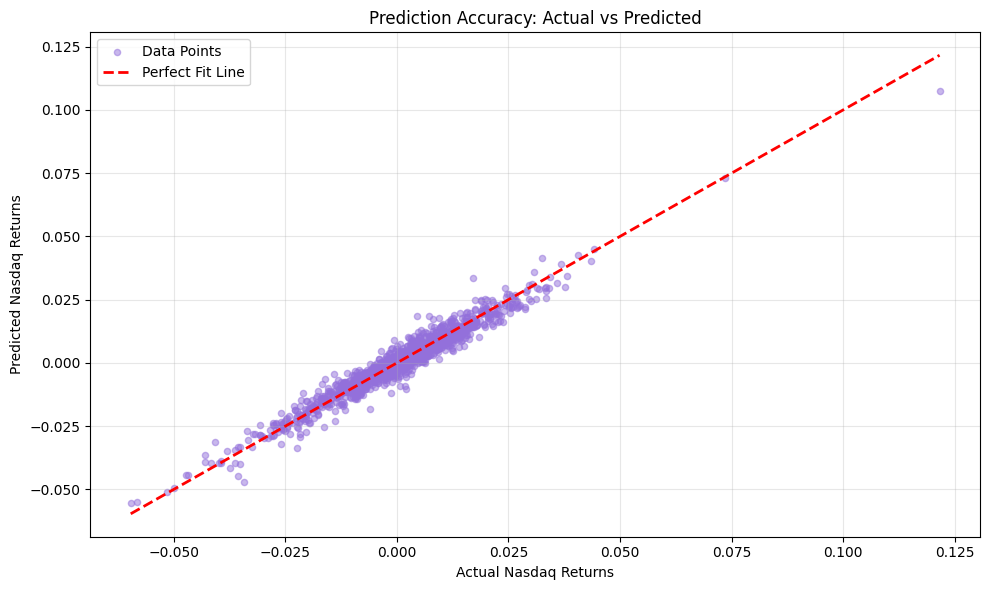

In [91]:
plt.figure(figsize=(10, 6))
plt.scatter(y, y_pred, alpha=0.5, color='mediumpurple', s=20, label='Data Points')
limit_min = min(y.min(), y_pred.min())
limit_max = max(y.max(), y_pred.max())
plt.plot([limit_min, limit_max], [limit_min, limit_max], 'r--', lw=2, label='Perfect Fit Line') # แก้เป็น r-- (แดงเส้นประ)
plt.title('Prediction Accuracy: Actual vs Predicted')
plt.xlabel('Actual Nasdaq Returns')
plt.ylabel('Predicted Nasdaq Returns')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Normality Test

In [92]:
# Residuals Calculation
residuals = y - y_pred
# To standardize residuals for KS test, we can use the formula: (residuals - mean) / std
residuals_std = (residuals - np.mean(residuals)) / np.std(residuals)
# Kolmogorov-Smirnov Test
ks_statistic, p_value = kstest(residuals_std, 'norm')

# Display KS Test Results
print(f"Kolmogorov-Smirnov (Statistic): {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
print("-" * 50)
print("Result Summary:")

# Summary of KS Test Result
alpha = 0.05
if p_value < alpha:
    print(f"\nResult of P-Value ({p_value:.4f}) < {alpha} -> Reject H0 (Data is NOT Normal Distribution)")
else:
    print(f"\nResult of P-Value ({p_value:.4f}) >= {alpha} -> Accept H0 (Data is Normal Distribution)")

Kolmogorov-Smirnov (Statistic): 0.0275
P-value: 0.2931
--------------------------------------------------
Result Summary:

Result of P-Value (0.2931) >= 0.05 -> Accept H0 (Data is Normal Distribution)


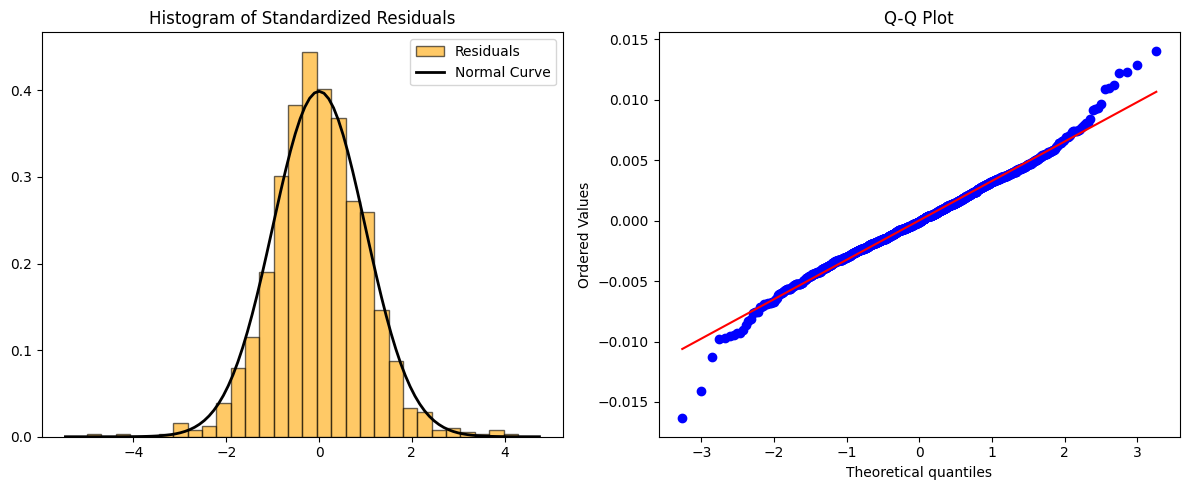

In [93]:
# Histogram & Q-Q Plot
plt.figure(figsize=(12, 5))

# Histogram of Standardized Residuals with Normal Curve
plt.subplot(1, 2, 1)
plt.hist(residuals_std, bins=30, density=True, alpha=0.6, color='orange', edgecolor='black', label='Residuals')
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2) # Standard Normal Equation
plt.plot(x, p, 'k', linewidth=2, label='Normal Curve')
plt.title('Histogram of Standardized Residuals')
plt.legend()

# Q-Q Plot
plt.subplot(1, 2, 2)
probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot')

# Plot Adjustments
plt.tight_layout()
plt.show()

### Independent Test

In [94]:
# Durbin-Watson Statistic Calculation
dw_stat = durbin_watson(residuals)

print(f"=== Durbin-Watson (DW-Test) Summary ===")
print(f"DW value: {dw_stat:.4f}")

# 4. แปลผล
if 1.5 < dw_stat < 2.5:
    print(f"Result: Value Between 1.5 and 2.5 -> No Autocorrelation")
elif dw_stat <= 1.5:
    print(f"Result: Value less than or equal to 1.5 -> Positive Autocorrelation")
else:
    print(f"Result: Value greater than 2.5 -> Negative Autocorrelation")

=== Durbin-Watson (DW-Test) Summary ===
DW value: 2.0446
Result: Value Between 1.5 and 2.5 -> No Autocorrelation


### Eqaulity Test

In [95]:
# Breusch-Pagan Test
# H0: Homoscedasticity 
# H1: Heteroscedasticity 
lm, p_lm, f_val, p_f = het_breuschpagan(residuals, MLR_model.model.exog)

print(f"=== Breusch-Pagan Test Summary ===")
print(f"LM Statistic: {lm:.4f}")
print(f"P-Value: {p_lm:.4f}")
print(f"F-Statistic: {f_val:.4f}")

# Summary of Breusch-Pagan Test Result
alpha = 0.05
if p_lm < alpha:
    print(f"\n Result of P-Value ({p_lm:.4f}) < {alpha} -> Reject H0")
    print("   Summary : Variance is Heteroscedasticity")
else:
    print(f"\n Result of P-Value ({p_lm:.4f}) >= {alpha} -> Accept H0")
    print("Summary: Variance is Homoscedasticity according to MLR assumptions")

=== Breusch-Pagan Test Summary ===
LM Statistic: 65.5023
P-Value: 0.0000
F-Statistic: 5.6993

 Result of P-Value (0.0000) < 0.05 -> Reject H0
   Summary : Variance is Heteroscedasticity


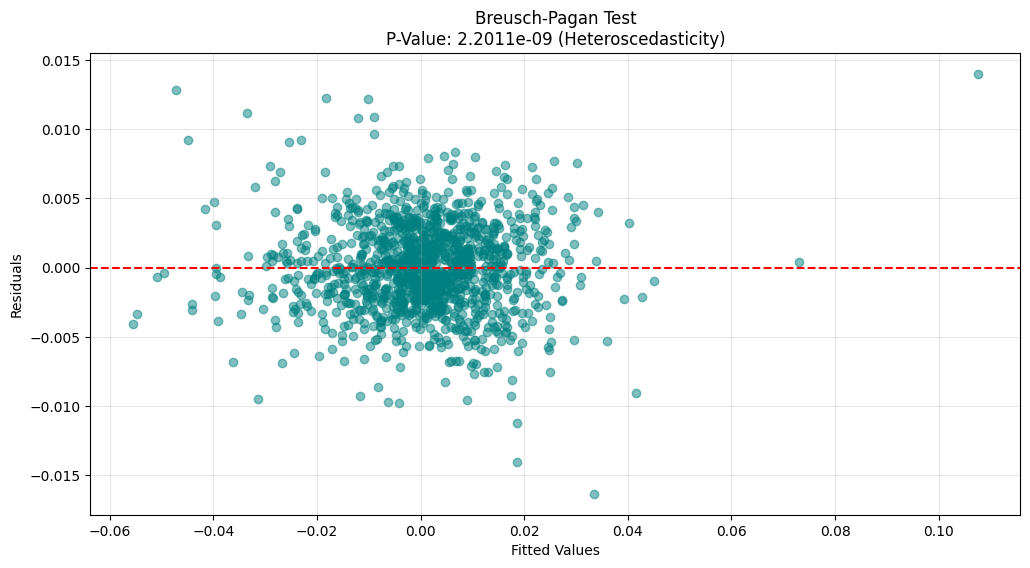

In [96]:
# Visualization of Residuals vs Fitted Values
plt.figure(figsize=(12, 6))
plt.scatter(MLR_model.fittedvalues, MLR_model.resid, alpha=0.5, color='teal')
plt.axhline(0, color='r', linestyle='--')
plt.title(f'Breusch-Pagan Test\nP-Value: {p_lm:.4e} ({"Heteroscedasticity" if p_lm < 0.05 else "Homoscedasticity"})')
plt.xlabel('Fitted Values'); plt.ylabel('Residuals')
plt.grid(True, alpha=0.3); plt.show()

### Adjust the Standard Error to be more durable by Heteroscedasticity Consistent (HC3)

In [97]:
results_robust = MLR_model.get_robustcov_results(cov_type='HC3')
print(results_robust.summary())

                            OLS Regression Results                            
Dep. Variable:          Nasdaq_Return   R-squared:                       0.947
Model:                            OLS   Adj. R-squared:                  0.947
Method:                 Least Squares   F-statistic:                     962.0
Date:                Sat, 28 Feb 2026   Prob (F-statistic):               0.00
Time:                        10:34:50   Log-Likelihood:                 5405.5
No. Observations:                1256   AIC:                        -1.078e+04
Df Residuals:                    1243   BIC:                        -1.072e+04
Df Model:                          12                                         
Covariance Type:                  HC3                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [98]:
# Create a DataFrame to analyze errors
df = pd.DataFrame({'Actual': y, 'Forecast': y_pred})
df['Absolute_Error'] = abs(df['Actual'] - df['Forecast'])
df['APE'] = (df['Absolute_Error'] / df['Actual']) * 100

# Sort by APE to find the top 10 instances with the highest percentage error
print(df.sort_values(by='APE', ascending=False).head(10))

               Actual  Forecast  Absolute_Error           APE
Date_Return                                                  
2025-01-09   0.000000 -0.000105        0.000105           inf
2025-07-04   0.000000 -0.000163        0.000163           inf
2025-05-26   0.000000  0.000022        0.000022           inf
2021-10-27   0.000009  0.006774        0.006765  7.935862e+04
2025-05-09   0.000043  0.003346        0.003302  7.596792e+03
2022-11-18   0.000099 -0.003322        0.003420  3.466642e+03
2024-01-11   0.000036  0.000842        0.000806  2.235348e+03
2022-01-26   0.000209  0.004671        0.004462  2.134528e+03
2024-11-21   0.000331 -0.006561        0.006892  2.081794e+03
2025-09-10   0.000300 -0.005454        0.005754  1.916169e+03


In [99]:
# Create a summary DataFrame for coefficients, robust p-values, and standard errors
summary_frame = pd.DataFrame({
    'Assets': X.columns,
    'Coefficient': results_robust.params,
    'P-Value (Robust)': results_robust.pvalues,
    'Standard Error': results_robust.bse
})

# Create a condition to filter significant variables at 95% confidence level
summary_frame['Is_Significant'] = summary_frame['P-Value (Robust)'] < 0.05

print("=== Robust Standard Errors Summary ===")
summary_frame = summary_frame.sort_values(by='P-Value (Robust)')
summary_frame = summary_frame.reset_index(drop=True)  # Reset index for better readability
print(summary_frame)
print("\n--- Adjusting Standard Errors to be Robust (Standard Errors) ---")
passed_vars = summary_frame[summary_frame['Is_Significant']].index.tolist()
print(f"Variables that are statistically significant at 95% confidence level: {passed_vars}")

=== Robust Standard Errors Summary ===
                       Assets  Coefficient  P-Value (Robust)  Standard Error  \
0                 TSLA_Return     0.056525      4.120410e-49        0.003670   
1                 AAPL_Return     0.157473      1.614027e-44        0.010807   
2                 NVDA_Return     0.106096      5.301506e-41        0.007626   
3                 AMZN_Return     0.102231      7.260925e-34        0.008178   
4                 MSFT_Return     0.127513      4.858066e-29        0.011113   
5       VIX_Fear_Index_Return    -0.027241      6.680431e-23        0.002710   
6                GOOGL_Return     0.074382      2.212414e-20        0.007900   
7                 META_Return     0.055323      2.519002e-12        0.007821   
8         Dollar_Index_Return    -0.088968      3.383819e-03        0.030300   
9   Treasury_Inflation_Return     0.045381      1.145124e-01        0.028734   
10                      const    -0.000127      1.714621e-01        0.000093   
1

### Save prediction Flie

In [100]:
df_returns['Predicted_Nasdaq'] = y_pred
df_returns['Error'] = residuals

In [ ]:
df_Predict = df_returns.reset_index()
df_Predict.rename(columns={'Date_Return': 'Date',
                    'AAPL_Return': 'AAPL',
                    'AMZN_Return': 'AMZN',
                    'WTI_Crude_Oil_Return': 'WTI_Crude_Oil',
                    'Dollar_Index_Return': 'Dollar_Index',
                    'COMEX_Gold_Return': 'COMEX_Gold',
                    'GOOGL_Return':'GOOGL',
                    'META_Return':'META',
                    'MSFT_Return': 'MSFT',
                    'NVDA_Return':'NVDA',
                    'Treasury_Inflation_Return':'Treasury_Inflation',
                    'TSLA_Return':'TSLA',
                    'Nasdaq_Return':'Nasdaq',
                    'VIX_Fear_Index_Return':'VIX_Fear_Index'},inplace=True)
df_Predict.head()

,Date,AAPL,AMZN,WTI_Crude_Oil,Dollar_Index,COMEX_Gold,GOOGL,META,MSFT,NVDA,Treasury_Inflation,TSLA,Nasdaq,VIX_Fear_Index,Predicted_Nasdaq_Return,Error_Return,Predicted_Nasdaq,Error
0,2021-01-05,0.012364,0.010004,0.048509,-0.004895,0.004114,0.008064,0.007548,0.000965,0.022210,-0.000313,0.007317,0.009490,-0.060437,0.009023,0.000467,0.009023,0.000467
1,2021-01-06,-0.033662,-0.024897,0.014020,0.001006,-0.023455,-0.009868,-0.028269,-0.025929,-0.058953,-0.002975,0.028390,-0.006098,-0.010655,-0.018380,0.012282,-0.018380,0.012282
2,2021-01-07,0.034123,0.007577,0.003950,0.003351,0.002832,0.029869,0.020622,0.028457,0.057830,-0.000628,0.079447,0.025641,-0.107698,0.026278,-0.000637,0.026278,-0.000637
3,2021-01-08,0.008631,0.006496,0.027740,0.003006,-0.040893,0.013239,-0.004354,0.006093,-0.005040,-0.003928,0.078403,0.010293,-0.036209,0.007494,0.002799,0.007494,0.002799
4,2021-01-11,-0.023249,-0.021519,0.000191,0.004883,0.008451,-0.023106,-0.040102,-0.009699,0.025967,-0.002130,-0.078214,-0.012540,0.116883,-0.016462,0.003923,-0.016462,0.003923


In [ ]:
output_filename = 'mag7_nasdaq_prediction_results.csv'
df_Predict.to_csv(output_filename, index=False)
print(f"Complete to save CSV: {output_filename}")

Complete to save CSV: mag7_nasdaq_prediction_results.csv
